# Lesson 147 · Next-generation architectures: turn gaps into experiments

Student lab · CPU only · PROVIDED / TODO / CHECK / EXIT. Complete visible evidence contracts, no new model. Tier B: saved real rel-f1 predictions, not synthetic benchmark data. Small synthetic fixtures test failure handling only. Three functions you write are called on all 7,554 held-out predictions or on the research map.

In [ ]:
# @colab-bootstrap: self-contained CPU audit; no repository or GPU required.
import sys,subprocess
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable,'-m','pip','install','-q','numpy==1.26.4'])
import base64,hashlib,io,json,math
from pathlib import Path
import numpy as np
from IPython.display import display,Markdown


<!-- sequence-review:start -->
<aside class="sequence-context" aria-label="Reading guide">
<p class="sequence-eyebrow">From a comparison to an investigation</p>
<p><strong>Reading route.</strong> Locate the information boundary → recheck the evidence → rank feasible questions → write a falsifier.</p>
<details><summary>Quick prerequisite reminder</summary><p>A mechanism describes how an operation could affect a prediction. A falsifier is a result that would refute a specific explanation. Transfer means reusing learned weights across tasks or databases; training new weights on another database is a different claim.</p></details>
</aside>
<!-- sequence-review:end -->

<p class="eyebrow">One win · turn an architecture claim into a testable research question</p>

[Previous: defend a comparison](https://avistian.github.io/relational/lessons/0146-gnn-vs-graph-transformer.html) · [Reference](https://avistian.github.io/relational/reference/next-generation-architectures.html) · [Student notebook](https://avistian.github.io/relational/labs/0147-next-generation-architectures.ipynb) · [Executed solution](https://avistian.github.io/relational/labs/html/0147-next-generation-architectures.html)



## 0 · Retrieve before you read

Recall: query identity includes entity and cutoff; attention cannot read excluded attributes; seeds do not create new databases.

Without looking back: what identifies a temporal prediction query? Can attention use attributes of a row that was never sampled? What does repeating a run with three seeds tell you that testing three databases would not?



## 1 · From a model catalogue to a research question

**Your mission is to make a defensible case for relational learning.** A list of promising architectures is not yet evidence. In Lessons 141–145 you traced how different models move information. Lesson 146 compared two reduced designs on one task. Now ask what that comparison leaves unresolved, and which next investigation could actually resolve it.

**The reading.** [Dwivedi et al., *Relational Deep Learning: Challenges, Foundations and Next-Generation Architectures*, v1](https://arxiv.org/html/2506.16654v1) organizes RDL around scale, temporal dynamics and heterogeneity. It connects relational entity graphs to established graph methods and discusses unified architectures and foundation models as research directions (§§2–5). Read §2.4, §4.1 and §5 first. This is a June 2025 source snapshot, not a claim to catalogue September 2026's frontier.

**A relational entity graph (REG)** has a node for each database row and edges for foreign-key references. **Heterogeneity** means different tables, relations and column modalities need different treatment. A **foundation model**, in this lesson's operational test, reuses pretrained weights across tasks or databases. A flexible architecture retrained from scratch on each database does not alone meet that test.

<figure class="research-figure" tabindex="0">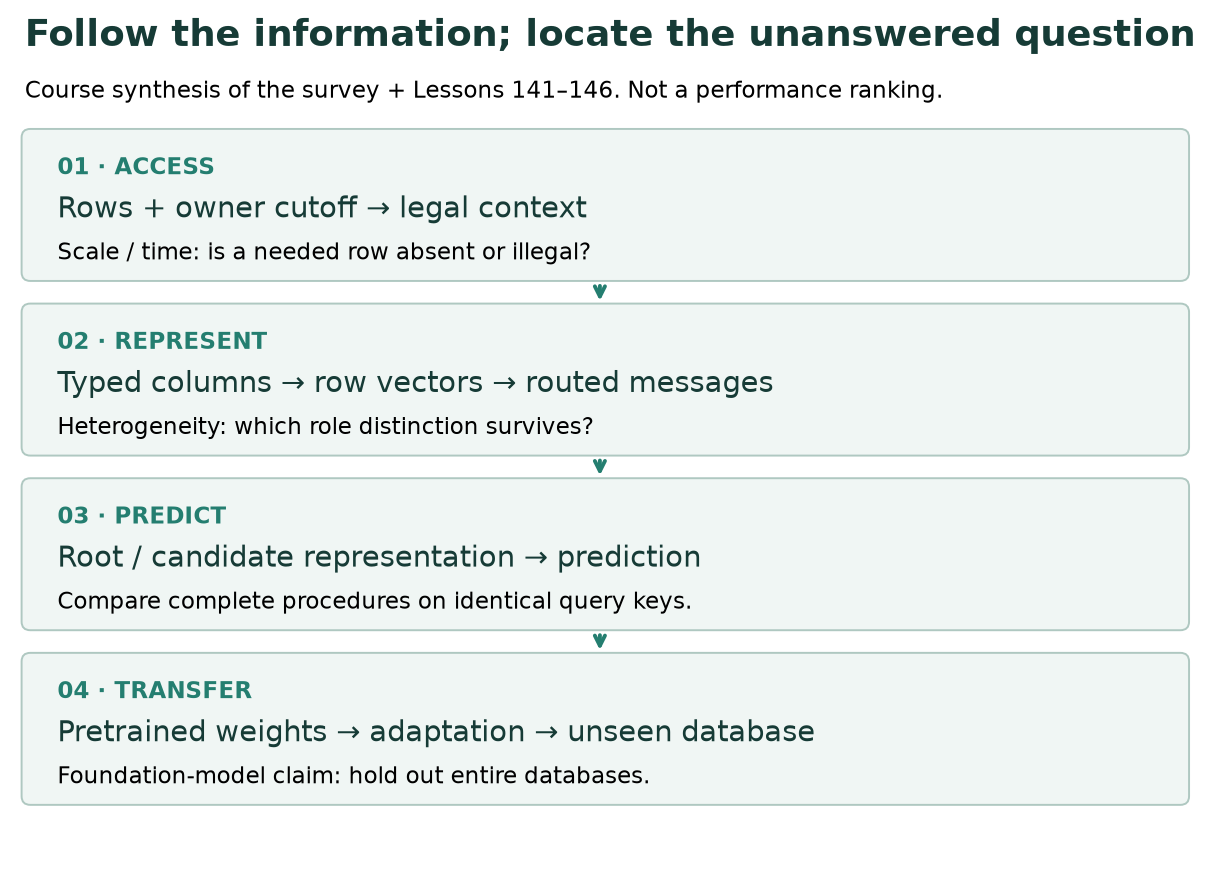<figcaption>Four distinct evidence boundaries: legal context, representation, prediction and transfer. Conceptual course synthesis, not a measured ranking. Scroll horizontally for detail on a narrow screen.</figcaption></figure>

The survey's model families suggest mechanisms: typed GNNs aggregate neighbors, RelGNN composes routes through facts, ContextGNN combines local and candidate-wide ranking, and RelGT mixes token encodings with local/global attention. Its transfer agenda requires evaluation beyond fitting a single database. See [§3](https://arxiv.org/html/2506.16654v1#S3), [§4.1](https://arxiv.org/html/2506.16654v1#S4.SS1), and [§5.2](https://arxiv.org/html/2506.16654v1#S5.SS2).

> **Scope check.** The map below is our course synthesis. A mechanism addressing a problem does not prove that the problem is solved. This lesson introduces no new model and claims no survey-wide experimental reproduction.



## 2 · Follow the information, then name the gap

> **In plain terms.** Ask where the required information could be lost before asking which model is most powerful.

Start with a query `(driver=7, cutoff=20)`. A sampler chooses legal rows for that particular query. A row encoder converts their columns into vectors. A propagation operator mixes information across the selected rows. A prediction head reads the root representation. Finally, a held-out evaluation tests the chosen training procedure. Each boundary creates a different research question.

**Choose the benchmark contract.** A task leaderboard compares procedures under particular splits and metrics. A foundation-model study additionally needs to identify which databases were excluded from pretraining. A row split cannot answer both questions. For the survey's benchmark inventory, read [§2.3](https://arxiv.org/html/2506.16654v1#S2.SS3); our executable evidence here is limited to the RelBench F1 task.

**Information access comes first.** If a useful row is absent, changing attention heads cannot expose its attributes. If a future row is present, encoding its age cannot establish permission to use it. These are logical properties of the input contract, not empirical accuracy claims. [L145's source audit](https://avistian.github.io/relational/labs/l145-reproduction.md) is a concrete case: ownership was lost in a cache keyed only by entity.

**Representation comes next.** A shared sum may merge distinct role assignments. A route-specific update can be tested against that collision, but only a target depending on the lost distinction makes the collision harmful. Recall [Lesson 142](https://avistian.github.io/relational/lessons/0142-many-to-many-edge-pathology.html): the target rule is part of the argument.

**Transfer asks a different question.** Training three seeds on F1 measures sensitivity to those runs under that task's protocol. It never changes the database. To test transfer, declare which databases are absent from pretraining, what adaptation data is allowed, and which scratch-trained baseline gets the same adaptation budget. That is an experimental proposal; this lesson does not execute it.

Baseline at four hours: selection → ownership → routes. At one hour only selection remains. At eight hours coverage enters. Transfer stays blocked because required inputs and protocol are missing.

**Predict, then intervene.** The baseline is four hours and $10 per candidate investigation. Reduce the time allowance to one hour; which questions remain feasible? Increase it to eight. Does the foundation-model question become ready? Why would more time alone fail to provide an uncontaminated pretraining corpus?



## 3 · Reproduce the evidence you actually have

Before reading: does reproducing six fits on F1 establish cross-database transfer? No; the database never changes.

**Held fixed:** the six saved L146 fits, their selected checkpoints and all held-out queries. **Varied:** only the order of prediction rows during the new audit. **Measured:** mean absolute error (MAE), the average distance between a prediction and its recorded target. The row shuffle must leave the score unchanged.

**Worked example.** Reference keys `(7,10)` and `(7,20)` have targets 1 and 5. Predictions arrive in reverse order: 5 and 3. Matching keys gives absolute errors 2 and 0, hence MAE 1. Matching positions gives 4 and 2, hence MAE 3. The same entity is insufficient identity because its cutoff changed.

The live notebook function rejects missing, extra and duplicate keys. It checks recorded targets against saved prepared targets before scoring. The new audit reuses those targets; it does not independently reconstruct labels from the raw database again.

<figure class="research-figure" tabindex="0">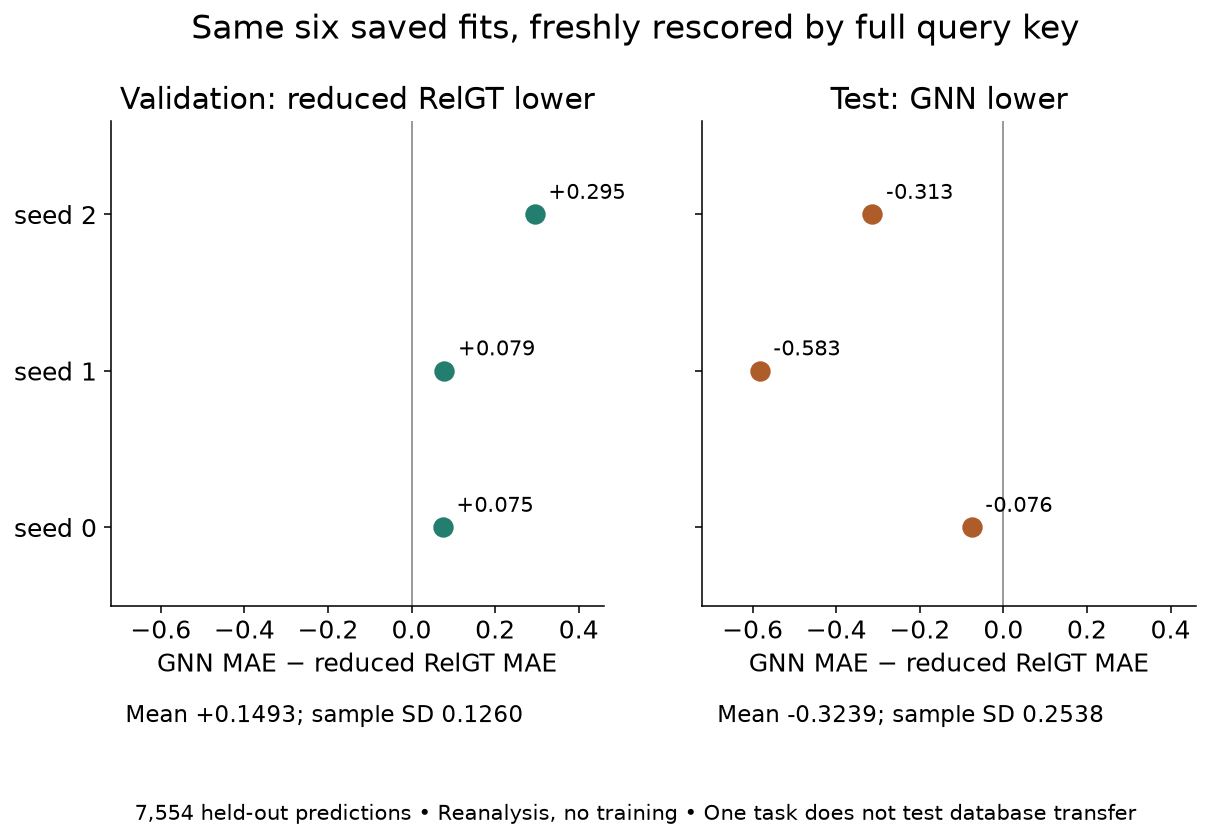<figcaption>Every point is one paired seed difference from saved L146 predictions, independently rescored in L147. SD describes three seeds, not uncertainty across databases. Scroll horizontally for detail on a narrow screen.</figcaption></figure>

| Seed | GNN validation | RelGT validation | GNN test | RelGT test |
|---|---:|---:|---:|---:|
| 0 | 3.222580 | 3.147865 | 4.261014 | 4.336655 |
| 1 | 3.132941 | 3.054402 | 4.335083 | 4.917953 |
| 2 | 3.237436 | 2.942668 | 4.284798 | 4.597999 |

Fresh reanalysis of **7,554 reused L146 predictions**. Paired validation difference **+0.149340 ± 0.125959**; test **−0.323904 ± 0.253784** MAE (mean ± sample seed SD). No fresh training.


For each seed, define **paired difference = GNN MAE − reduced RelGT MAE**. Positive values favor reduced RelGT; negative values favor the GNN. Calculate each seed difference first, then report their mean and **sample standard deviation**, a measure of spread across these three seeds. This is not a confidence interval or a population-wide probability of superiority.

**What follows?** The conditional ordering reverses between the two splits. That motivates checking selection stability, context coverage or error slices. It does not isolate attention as the cause: the arms differ in several mechanisms. Reusing this familiar test set for new hypotheses makes the next analyses exploratory. Confirmatory claims need a protocol and evaluation population not chosen after inspecting these errors.



## 4 · Rank questions without manufacturing certainty

A **falsifier** is an observable result that would refute the specific claim you propose. “Try a bigger transformer” lacks one. “The missing circuit rows explain the error gap” can be challenged by measuring whether those rows are already present.

Our map records a mechanism, unresolved gap, minimal test, held-fixed variables and falsifier for each question. It also records planning assumptions. **Hours** estimate investigation effort, not measured runtime. **Dollars** describe the proposed local investigation, not training a new model. **Ready** means the required inputs and protocol are available for that investigation.

**Evidence levels are a declared course rubric:** 3 = a local empirical audit directly motivates the question; 2 = a controlled mechanism example; 1 = an architectural argument; 0 = an untested transfer proposal. They describe the basis for asking, not the likelihood that a new method will succeed.

Our deliberately simple policy filters by readiness, hours and dollars; sorts remaining questions by evidence level descending, effort ascending, then stable ID. It does not add ordinal evidence levels to dollars. Each candidate is considered separately: the result is not a portfolio whose total effort fits the limit.

<figure class="research-figure" tabindex="0">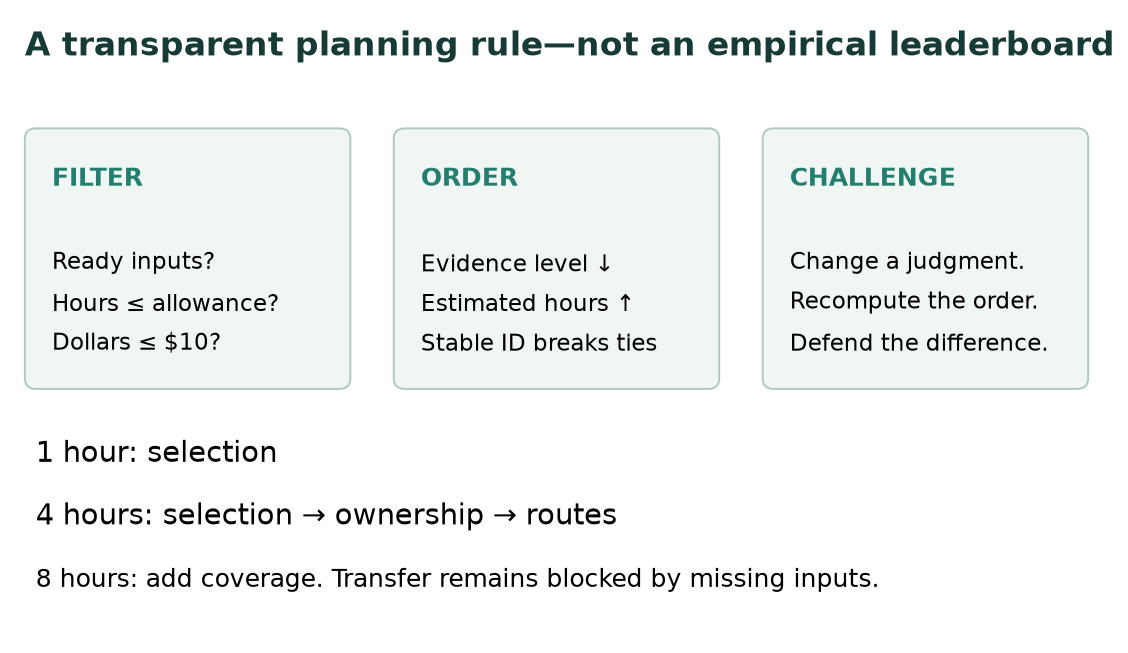<figcaption>Declared planning assumptions produce different feasible sets. An ordering is conditional on those judgments; it is not a measured probability of research success. Scroll horizontally for detail on a narrow screen.</figcaption></figure>

**Worked example.** At four hours, the ranking is selection → ownership → routes. Coverage needs an estimated six hours. Transfer is not ready even with forty hours because a corpus and held-out-database protocol are missing. The forty-hour/$10 entry is an illustrative placeholder, not a priced foundation-model training plan. Your job is to challenge these judgments before treating the ordering as advice.

**Sensitivity exercise.** Change ownership's evidence level from 3 to 1 in the notebook. Predict the new order before running. Then argue whether that edit reflects weaker evidence or merely your preference. The ranking cannot make that distinction for you.



## 5 · Lab: write the contracts, then defend one question

The portable [student lab](https://avistian.github.io/relational/labs/0147-next-generation-architectures.ipynb) contains all audit inputs and diagrams. It needs NumPy, no GPU or repository checkout. Three TODOs implement the actual functions used in the full reanalysis: keyed losses, paired summaries and feasibility-first ranking. Each has immediate rejection checks. The [executed solution](https://avistian.github.io/relational/labs/html/0147-next-generation-architectures.html) is author-reference evidence, not evidence of your mastery.

**EXIT deliverable:** export your revised open-problems map and write 150–250 words choosing one investigation. Include the hypothesis, minimum test, fixed quantities, falsifier, cost assumptions and one claim the current evidence cannot support. Explain how your proposal connects to the mission. Next, Lesson 148 will separate encoder, propagation and graph-construction effects with ablations—controlled removals or substitutions of one component.

Write: choose one unresolved mechanism, a minimal falsifiable test and a claim your current evidence cannot support. Ask the teaching agent for feedback.



## 6 · Full reproduction: keep the boundary visible

The survey provides a synthesis, not a new training table to rerun. The named retained experiment is **RelGT v1 Table 1, rel-f1/driver-position**. Its complete released lane has nine configurations, each trained for 100 epochs. The original model, trainer, source pins and data contract remain linked in the [L145 reproduction protocol](https://avistian.github.io/relational/labs/l145-reproduction.md); the [safe preflight](https://avistian.github.io/relational/labs/_reproduce_l146.py) inspects the inherited blockers without allocating compute.

**Full selected reproduction remains INCOMPLETE.** The source temporal audit failed. The inherited shallow-pilot extrapolation is approximately $80.41 for the nine configurations before overhead, with deeper configurations unmeasured. That is not a fresh price estimate. No complete search is launched under this lesson's $10 aggregate cap. Whole-paper reproduction is NOT_RUN and historical identity is NOT_ESTABLISHED. Corrected reduced course runs cannot close either gap.

**L147 execution:** fresh CPU reanalysis, reused fits and targets, $0 cloud spend. [Protocol and commands](https://avistian.github.io/relational/labs/l147-reproduction.md) · [Visible audit functions](https://avistian.github.io/relational/labs/relkit/survey_l147.py) · [Input hashes](https://avistian.github.io/relational/labs/evidence/l147/input-hashes.json) · [Question ledger](https://avistian.github.io/relational/labs/evidence/l147/questions.json).

Ask the teaching agent about any unclear mechanism, or submit your EXIT defense for feedback. Return tomorrow and reconstruct your chosen question's falsifier without opening the map.


<!-- sequence-next:start -->
**Carry this forward.** Bring one hypothesis to Lesson 148 and state the smallest intervention that could test it, including everything that must remain fixed. [Continue to Lesson 148](https://avistian.github.io/relational/lessons/0148-ablation-discipline.html).
<!-- sequence-next:end -->


In [ ]:
# PROVIDED: immutable author inputs, not newly trained predictions.
raw=base64.b64decode('...')
assert hashlib.sha256(raw).hexdigest()=='e3a985833e2068336133d5ac360f384c7255ad877fe60609a684ec8063227b31'
DATA=np.load(io.BytesIO(raw),allow_pickle=False)
QUESTIONS=json.loads('[{"id": "ownership", "title": "Does the token cache preserve query ownership?", "problem": "temporal dynamics", "mechanism": "Query-keyed sampling before expansion", "gap": "Time encoding cannot make an illegally sampled row legal.", "test": "Permute two cutoffs of the same entity; compare selected row timestamps with each owner cutoff.", "falsifier": "Any selected dated row is later than its owner cutoff.", "held_fixed": "Graph rows, queries, sample size and model weights", "hours": 2, "usd": 0, "evidence": 3, "ready": true, "basis": "L145 source audit; a local forensic contract, not a new architecture result", "source": "https://arxiv.org/html/2506.16654v1#S4.SS3"}, {"id": "selection", "title": "Does the validation advantage persist on test?", "problem": "evaluation", "mechanism": "Keyed, paired seed evaluation", "gap": "The L146 reversal does not identify its cause.", "test": "Rescore the six saved fits; report both splits and every paired seed.", "falsifier": "A valid seed pair loses its validation advantage on test. Missing keys or changed targets instead block interpretation.", "held_fixed": "All fitted weights, queries and selected checkpoints", "hours": 1, "usd": 0, "evidence": 3, "ready": true, "basis": "L146 full-data course predictions; reanalysis completed here", "source": "https://arxiv.org/html/2505.10960v1#A4"}, {"id": "routes", "title": "Does a route-specific update retain role information?", "problem": "heterogeneity", "mechanism": "Composite source\\u2013fact\\u2013destination messages", "gap": "A representation collision may be irrelevant to the downstream target.", "test": "Construct paired role-swapped inputs and declare a role-sensitive target before inspecting outputs.", "falsifier": "The chosen representation remains identical while the declared target changes.", "held_fixed": "Rows, target rule and numerical features", "hours": 3, "usd": 0, "evidence": 2, "ready": true, "basis": "L142 controlled collision example; estimated follow-up effort", "source": "https://arxiv.org/html/2506.16654v1#S4.SS1"}, {"id": "coverage", "title": "Is context coverage the limiting resource?", "problem": "scale", "mechanism": "Sampled local attention plus global summaries", "gap": "More attention layers cannot read a row excluded by the sampler.", "test": "Profile legal coverage and memory at K=16,32,64 on fixed queries before proposing training.", "falsifier": "The alleged missing relevant rows are already present in the fixed context.", "held_fixed": "Query list, cutoff rule, graph materialization and sampling seed", "hours": 6, "usd": 0, "evidence": 1, "ready": true, "basis": "L146 mechanism motivates a new profiling study; six hours is a planning estimate", "source": "https://arxiv.org/html/2506.16654v1#S3.SS4"}, {"id": "transfer", "title": "Do pretrained weights transfer across unseen databases?", "problem": "foundation models", "mechanism": "Shared schema/row representations and adaptation", "gap": "Within-F1 seed replication contains no held-out database.", "test": "Freeze a pretraining corpus and hold out entire databases, with matched scratch baselines and adaptation budgets.", "falsifier": "Pretrained weights fail the predeclared held-out-database improvement criterion.", "held_fixed": "Target tasks, adaptation data, budget and selection rules", "hours": 40, "usd": 10, "evidence": 0, "ready": false, "basis": "Illustrative lower-bound planning placeholder, NOT a priced training estimate; corpus and protocol unavailable", "source": "https://arxiv.org/html/2506.16654v1#S5.SS2"}]')
AUTHOR_SUMMARY=json.loads('{"status": "PASS", "scope": "Fresh reanalysis of REUSED L146 predictions; no training", "verified_predictions": 7554, "runs": [{"arm": "gnn", "seed": 0, "val": 3.2225796778518996, "test": 4.261014471681494}, {"arm": "gnn", "seed": 1, "val": 3.1329407902184374, "test": 4.335083300021657}, {"arm": "gnn", "seed": 2, "val": 3.2374364118378565, "test": 4.2847977102848525}, {"arm": "relgt", "seed": 0, "val": 3.1478653464384214, "test": 4.3366547067541825}, {"arm": "relgt", "seed": 1, "val": 3.0544019114278367, "test": 4.9179529318893165}, {"arm": "relgt", "seed": 2, "val": 2.9426681637047287, "test": 4.597998990050534}], "paired": {"val": {"seeds": [0, 1, 2], "differences": [0.07471433141347816, 0.07853887879060073, 0.29476824813312774], "mean": 0.14934048611240222, "sample_sd": 0.12595865299941703}, "test": {"seeds": [0, 1, 2], "differences": [-0.07564023507268836, -0.5828696318676592, -0.31320127976568113], "mean": -0.3239037155686762, "sample_sd": 0.2537840062776522}}, "ranking": ["selection", "ownership", "routes"], "ranking_one_hour": ["selection"], "full_selected_reproduction": "INCOMPLETE", "whole_paper": "NOT_RUN", "historical_identity": "NOT_ESTABLISHED", "cloud_spend_usd": 0, "learner": "PENDING_WRITTEN_DEFENSE", "reference_boundary": "Prepared L146 targets reused; raw label reconstruction not rerun"}')

## TODO · `keyed_losses`

Align full keys, reject duplicate/missing/extra identities, nonfinite values and target disagreements, then return absolute losses in reference order.

Predict the first fixture result before running the CHECK. This is the live function used below.

In [ ]:
def keyed_losses(reference_keys, reference_targets, run_keys, run_targets, predictions):
    raise NotImplementedError("TODO: keyed_losses")

In [ ]:
def check_keyed_losses(fn):
    keys=[(7,10),(7,20),(8,10)]
    out=fn(keys,[1,5,9],[(8,10),(7,10),(7,20)],[9,1,5],[8,3,5])
    np.testing.assert_array_equal(out,[2,0,1])
    cases=[(keys[:2],[1,5],[2,5]), ([(7,10),(7,10),(8,10)],[1,1,9],[2,2,8]),
           (keys,[1,6,9],[2,5,8]), (keys,[1,5,9],[2,float('nan'),8]),
           ([(7,10),(7,20),(9,10)],[1,5,9],[2,5,8])]
    for k,t,p in cases:
        try: fn(keys,[1,5,9],k,t,p)
        except ValueError: pass
        else: raise AssertionError('Reject missing/duplicate/extra keys, changed targets and nonfinite predictions')
    try: fn(keys+[keys[0]],[1,5,9,1],keys,[1,5,9],[2,5,8])
    except ValueError: pass
    else: raise AssertionError('Reference duplicates must fail')
check_keyed_losses(keyed_losses)
print("PASS: keyed_losses")

## TODO · `paired_summary`

Require matching sets of at least two seeds. Return sorted seeds, left-minus-right differences, their mean and sample SD (ddof=1).

Predict the first fixture result before running the CHECK. This is the live function used below.

In [ ]:
def paired_summary(left, right):
    raise NotImplementedError("TODO: paired_summary")

In [ ]:
def check_paired_summary(fn):
    got=fn({2:4,0:2,1:3},{1:2,2:3,0:3})
    np.testing.assert_allclose(got['differences'],[-1,1,1])
    assert abs(got['mean']-1/3)<1e-12
    assert abs(got['sample_sd']-np.sqrt(4/3))<1e-12
    for a,b in [({0:2},{1:3}),({0:2},{0:3}),({0:2,1:np.nan},{0:3,1:4})]:
        try: fn(a,b)
        except ValueError: pass
        else: raise AssertionError('Need matching seed sets, at least two seeds and finite scores')
check_paired_summary(paired_summary)
print("PASS: paired_summary")

## TODO · `rank_questions`

Validate planning inputs; filter readiness and limits; order by evidence descending, hours ascending, then ID. Return IDs. Reject duplicate IDs and invalid costs.

Predict the first fixture result before running the CHECK. This is the live function used below.

In [ ]:
def rank_questions(rows, max_hours, max_usd):
    raise NotImplementedError("TODO: rank_questions")

In [ ]:
def check_rank_questions(fn):
    rows=[dict(id='b',hours=2,usd=0,evidence=2,ready=True),
          dict(id='a',hours=1,usd=0,evidence=1,ready=True),
          dict(id='c',hours=1,usd=0,evidence=3,ready=False),
          dict(id='d',hours=2,usd=11,evidence=3,ready=True)]
    assert fn(rows,2,10)==['b','a']
    assert fn(rows,1,10)==['a']
    assert fn(rows,2,0)==['b','a']
    assert fn(rows,0,10)==[]
    assert fn(rows+[dict(id='z',hours=2,usd=0,evidence=2,ready=True)],2,10)==['b','z','a']
    try: fn(rows+[rows[0]],2,10)
    except ValueError: pass
    else: raise AssertionError('Duplicate question IDs must fail')
    try: fn([dict(id='x',hours=-1,usd=0,evidence=1,ready=True)],2,10)
    except ValueError: pass
    else: raise AssertionError('Negative planning cost must fail')
check_rank_questions(rank_questions)
print("PASS: rank_questions")

## CHECK · full evidence reanalysis

Targets come from saved L146 preparation. Raw database labels are not regenerated here. Predictions are shuffled deliberately; scores must remain unchanged. Original input hashes and source protocol are linked in the lesson.

In [ ]:
# CHECK: your live functions rescore every saved prediction after shuffling rows.
means={s:{a:{} for a in ['gnn','relgt']} for s in ['val','test']}
verified=0;rows=[]
for arm in ['gnn','relgt']:
    for seed in [0,1,2]:
        row={'arm':arm,'seed':seed}
        for split in ['val','test']:
            key=f'{arm}_{seed}_{split}_';ref=f'ref_{split}_'
            n=len(DATA[ref+'target']);order=np.random.default_rng(147+seed).permutation(n)
            losses=keyed_losses(list(zip(DATA[ref+'entity'],DATA[ref+'cutoff'])),DATA[ref+'target'],
                list(zip(DATA[key+'entity'][order],DATA[key+'cutoff'][order])),
                DATA[key+'target'][order],DATA[key+'pred'][order])
            means[split][arm][seed]=float(losses.mean());row[split]=float(losses.mean());verified+=n
        rows.append(row)
paired={s:paired_summary(means[s]['gnn'],means[s]['relgt']) for s in means}
assert verified==7554
for split in paired:
    np.testing.assert_allclose(paired[split]['differences'],AUTHOR_SUMMARY['paired'][split]['differences'],rtol=0,atol=1e-12)
table='| Arm | Seed | Validation MAE | Test MAE |\n|---|---:|---:|---:|\n'
for r in rows:table+=f"| {r['arm']} | {r['seed']} | {r['val']:.6f} | {r['test']:.6f} |\n"
display(Markdown(table.replace('\\n','\n')))
for split,d in paired.items():print(split, 'GNN minus RelGT:',round(d['mean'],6),'+/-',round(d['sample_sd'],6),'sample seed SD')
print('Freshly rescored reused predictions:',verified)


## CHECK · change an assumption, not a measured score

Predict what happens if ownership has evidence level 1 instead of 3. The sensitivity case below is hypothetical; it does not rewrite the author ledger.

In [ ]:
baseline=rank_questions(QUESTIONS,4,10)
assert baseline==['selection','ownership','routes']
changed=[dict(q,evidence=1) if q['id']=='ownership' else dict(q) for q in QUESTIONS]
assert rank_questions(changed,4,10)==['selection','routes','ownership']
assert 'transfer' not in rank_questions(QUESTIONS,40,10)
print('Baseline:',baseline)
print('Changed judgment:',rank_questions(changed,4,10))
MY_QUESTIONS=[dict(q) for q in QUESTIONS]  # Revise assumptions and justify them in your EXIT.
Path('l147-open-problems.json').write_text(json.dumps(MY_QUESTIONS,indent=2))

## EXIT · your research defense

Write 150–250 words covering a hypothesis, minimal test, fixed quantities, falsifier, cost assumptions and unsupported claim. Modify `MY_QUESTIONS` and rerun its export when needed. Submit the map and defense to the teaching agent. Automated checks do not grade your scientific judgment.

In [ ]:
report=dict(status='PASS',verified_author_predictions=verified,paired=paired,ranking=baseline,cloud_spend_usd=0,fresh_training='NOT_RUN',full_selected_reproduction='INCOMPLETE',learner='PENDING_WRITTEN_DEFENSE')
Path('l147-report.json').write_text(json.dumps(report,indent=2))
print('Saved evidence report and open-problems map; written defense remains pending.')

## Paper-results lane · retained without launching compute

The survey has no new training experiment. Named retained lane: RelGT v1 Table 1, F1 driver-position. [Complete original model](https://avistian.github.io/relational/labs/relkit/relgt_l145.py), [complete trainer](https://avistian.github.io/relational/labs/_full_l145.py), [source/data/optimizer/selection/seed ledger](https://avistian.github.io/relational/labs/l145-reproduction.md), [safe preflight](https://avistian.github.io/relational/labs/_reproduce_l146.py). From the repository run `.venv/bin/python labs/_reproduce_l146.py --audit`. The full `.venv/bin/modal run modal/l145_repro.py::full` command is guarded and currently stops: source temporal FAIL and complete search exceeds the standing budget. No training call or forensic override is hidden in this notebook. Nine 100-epoch fits NOT_RUN; historical identity NOT_ESTABLISHED. L147 audit completion does not change these statuses.